### **Modern Data Architecture in Big Data 1**

# **Parking Analysis in Seattle**

#### Seattle ranks among the top 10 most congested cities in the United States. The objective of our analysis is to help the *Seattle Department of Transportation (Seattle SDOT)* determine **how to optimise parking spaces in the city**.

To do so, we will be adopting a three-step approach answering the following business questions:
1. How does utilisation vary across Seattle?
2. How does utilisation vary across the years?
3. Are prices aligned with the different demand study areas?

#### We will be using these 2 datasets to analyse the parking spaces in Seattle:

- **Dataset 1: Annual Parking Study Data (csv file)** - Covers the period of 2014 to 2019 (https://data.seattle.gov/Transportation/Annual-Parking-Study-Data/7jzm-ucez)
- **Dataset 2: Paid Parking Transaction Data (json file)** - Covers 1 week of data from 29 November 2025 to 5 December 2025 (https://data.seattle.gov/Transportation/Paid-Parking-Transaction-Data/gg89-k5p6/about_data)

## **1. Initiating Spark Session:** Embarking on our Analysis Process

In [1]:
from pyspark.sql.session import SparkSession

spark_session = \
  SparkSession.builder\
              .appName("parking")\
              .getOrCreate()

print(f"This cluster relies on Spark '{spark_session.version}'")

25/12/18 12:38:28 WARN Utils: Your hostname, osbdet resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s1)
25/12/18 12:38:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/18 12:38:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


This cluster relies on Spark '3.5.4'


In [2]:
import pyspark.sql.functions as F
import pyspark.sql.types as T

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
# Tell Spark Session to access MinIO
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key", "s3access")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key", "_s3access123$")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.path.style.access", "true")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
spark_session.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.endpoint", "http://localhost:9000")

In [6]:
csv_df = spark_session.read\
                         .option("header","true")\
                         .option("inferSchema","true")\
                         .csv("s3a://parking/csv/")
csv_df.limit(5).toPandas()

25/12/18 12:38:42 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM


In [7]:
json_df = spark_session.read\
                        .option("multiLine","true")\
                        .json("s3a://parking/json/")

json_df.limit(5).toPandas()

,amount_paid,blockface_name,durationinminutes,elementkey,latitude,longitude,meter_code,parkingspacenumber,payment_mean,sideofstreet,transaction_id,transactiondatetime
0,2.00,24TH AVE NW BETWEEN NW 57TH ST AND NW 58TH ST,120,26497,47.67055033000000,-122.38770911000000,11121004,None,PHONE,W,1535580879,2025-11-29T08:00:00.000
1,14.50,BOREN AVE BETWEEN FAIRVIEW AVE AND DENNY WAY,240,77261,47.61812378000000,-122.33485267000000,21098004,None,PHONE,SW,1535580952,2025-11-29T08:00:00.000
2,4.00,5TH AVE BETWEEN BELL ST AND BATTERY ST,240,52526,47.61647857000000,-122.34364660000000,10346004,None,PHONE,NE,1535559424,2025-11-29T08:00:00.000
3,7.00,QUEEN ANNE AVE N BETWEEN THOMAS ST AND HARRISO...,240,80277,47.62150584000000,-122.35681515000000,17073004,None,PHONE,W,1535562841,2025-11-29T08:00:00.000
4,5.00,LENORA ST BETWEEN 8TH AVE AND 9TH AVE,120,56694,47.61675811000000,-122.33742376000000,21600004,None,PHONE,SE,1535565306,2025-11-29T08:00:00.000


## **2. Data Cleaning:**  Everything Everywhere All at Once about Data Quality and Integrity

After both datasets are loaded from MinIO, we will now proceed to clean the datasets, before proceeding with our Exploratory Data Analysis (EDA).

In [8]:
# Check datatype for each column
csv_df.printSchema()
json_df.printSchema()

root
 |-- Elmntkey: string (nullable = true)
 |-- Study_Area: string (nullable = true)
 |-- Sub_Area: string (nullable = true)
 |-- Date Time: string (nullable = true)
 |-- Side: string (nullable = true)
 |-- Unitdesc: string (nullable = true)
 |-- Peak Hour_SDOT: string (nullable = true)
 |-- Parking_Spaces: string (nullable = true)
 |-- Total_Vehicle_Count: string (nullable = true)
 |-- Dp_Count: string (nullable = true)
 |-- Rpz_Count: integer (nullable = true)
 |-- TG_Car2Go: integer (nullable = true)
 |-- BMW_DN: integer (nullable = true)
 |-- Lime: integer (nullable = true)
 |-- Idling: integer (nullable = true)
 |-- Field Notes: string (nullable = true)
 |-- Construction: string (nullable = true)
 |-- Event Closure: string (nullable = true)
 |-- Subarea Label: string (nullable = true)
 |-- Study Year: integer (nullable = true)
 |-- Peak Hour? (Yes or No): string (nullable = true)
 |-- RPZ Blocks: integer (nullable = true)
 |-- CSM: string (nullable = true)
 |-- Time Stamp: strin

From the above printSchema and the dataframe preview generated in Part 1 above, we can see that both datasets have 2 similar columns - Element Key (csv: Elmnt Key, json: elementkey) and Side of Street (csv: Side, json: sideofstreet). Element key will be the main column to lookup values across both datasets.

In [9]:
# Check unique values in all columns in csv first
for col_name in csv_df:
    print(f"Unique values in column: {col_name}")
    csv_df.select(col_name).distinct().show(50, truncate=False)
    print(" ")

Unique values in column: Column<'Elmntkey'>


+--------+
|Elmntkey|
+--------+
|79785   |
|32558   |
|58197   |
|81206   |
|120166  |
|58185   |
|54609   |
|78073   |
|1090    |
|70170   |
|31518   |
|54073   |
|12542   |
|54729   |
|35438   |
|63126   |
|70758   |
|80593   |
|8306    |
|56081   |
|53430   |
|11106   |
|69086   |
|10801   |
|79582   |
|81510   |
|13170   |
|80185   |
|69306   |
|17438   |
|76358   |
|81125   |
|53806   |
|35349   |
|13805   |
|13133   |
|81194   |
|58490   |
|12957   |
|36157   |
|14697   |
|11878   |
|79021   |
|58382   |
|123943  |
|68922   |
|86449   |
|78782   |
|77261   |
|56685   |
+--------+
only showing top 50 rows

 
Unique values in column: Column<'Study_Area'>
+--------------------------------+
|Study_Area                      |
+--------------------------------+
|Cherry Hill                     |
|Denny Triangle North            |
|Chinatown/ID - Sunday           |
|Commercial Core - Weekday       |
|Roosevelt - Weekday             |
|Ballard Locks                   |
|University Distr

In [10]:
# Check unique values in all columns in json first
for col_name in json_df:
    print(f"Unique values in column: {col_name}")
    json_df.select(col_name).distinct().show(50, truncate=False)
    print(" ")

Unique values in column: Column<'amount_paid'>
+-----------+
|amount_paid|
+-----------+
|24.50      |
|13.87      |
|7.16       |
|23.97      |
|17.42      |
|0.55       |
|4.13       |
|12.85      |
|2.43       |
|11.83      |
|3.89       |
|8.41       |
|14.20      |
|26.25      |
|23.92      |
|38.00      |
|6.40       |
|11.88      |
|12.35      |
|0.07       |
|17.90      |
|8.58       |
|4.33       |
|5.42       |
|7.65       |
|4.96       |
|17.52      |
|1.19       |
|23.34      |
|10.97      |
|5.45       |
|2.78       |
|8.49       |
|5.78       |
|19.10      |
|7.47       |
|2.20       |
|4.48       |
|10.93      |
|10.77      |
|3.04       |
|9.32       |
|15.35      |
|14.50      |
|5.00       |
|0.75       |
|1.30       |
|9.03       |
|14.60      |
|4.54       |
+-----------+
only showing top 50 rows

 
Unique values in column: Column<'blockface_name'>
+-----------------------------------------------------------+
|blockface_name                                          

As seen in the unique values of string columns extracted from the csv file, we observe that the data quality of the datasets is not the best.

In the **csv** file:
- `Study_Area`: Contains many inconsistent and likely manually entered variations of related areas. Standardisation is required for reliable area-level analysis.
- `Side`: Expected direction codes (e.g. N, S, E, W etc.) are mixed with other numbers and letters. Since the json file contains a cleaner `sideofstreet` column, we will clean this column with a lookup to the json data.
- `Total_Vehicle_Count`: Contains invalid negative values - these rows will be removed.
- `Construction`, `Event Closure`, `Peak Hour`: These are supposed to be boolean columns, and also include inconsistent formats (e.g. "Yes" vs "yes"). Standardisation is required here.

In the **json** file:
- `durationinminutes`: There are negative values here which do not make sense - these rows will be removed.

### **2.1. Fixing Specific Columns**

To minimise the changes made to the original dataset, we first create new dataframes to store the cleaned data.
- `cleaned_csv_df`
- `cleaned_json_df`

In [11]:
cleaned_csv_df = csv_df
cleaned_json_df = json_df

#### **2.1.1. csv**

#### *A. Clean `Study_Area` column (csv)*

In [12]:
csv_df.select("Study_Area").distinct()\
                            .orderBy("Study_Area")\
                            .show(csv_df.select("Study_Area").distinct().count(), truncate=False)

+---------------------------------------------------------------+
|Study_Area                                                     |
+---------------------------------------------------------------+
|NULL                                                           |
| 1-6p; x2"                                                     |
| 3-6p                                                          |
| carpool 7-10 am"                                              |
| if anyone parked there between 7-5:30 I marked it as illegal."|
|12th Ave                                                       |
|12th Ave - Weekday                                             |
|12th Ave 2017 Annual Study                                     |
|12th Avenue                                                    |
|15th Avenue                                                    |
|Ballard                                                        |
|Ballard - Weekday                                              |
|Ballard L

In [13]:
# Create a new column - Study_Area_cleaned_L2
cleaned_csv_df = csv_df.withColumn("Study_Area_cleaned_L2", F.col("Study_Area"))

In [14]:
# Remove invalid values
invalid_values = [" 1-6p; x2\"",
                  " 3-6p",
                  " carpool 7-10 am\"",
                  " if anyone parked there between 7-5:30 I marked it as illegal.\"",
                  "No",
                  "Yes",
                  None]

cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.when(F.col("Study_Area_cleaned_L2").isin(invalid_values), None)
                                           .otherwise(F.col("Study_Area_cleaned_L2")))

cleaned_csv_df.select("Study_Area_cleaned_L2")\
                .distinct()\
                .orderBy("Study_Area_cleaned_L2")\
                .show(cleaned_csv_df.select("Study_Area_cleaned_L2").distinct().count(), truncate=False)

+--------------------------------+
|Study_Area_cleaned_L2           |
+--------------------------------+
|NULL                            |
|12th Ave                        |
|12th Ave - Weekday              |
|12th Ave 2017 Annual Study      |
|12th Avenue                     |
|15th Avenue                     |
|Ballard                         |
|Ballard - Weekday               |
|Ballard Locks                   |
|Ballard Locks - Weekday (Spring)|
|Ballard Locks - Weekday (Summer)|
|Ballard Locks Spring            |
|Ballard Locks Spring 2017       |
|Ballard Locks Summer            |
|Ballard Locks summer            |
|Belltown                        |
|Belltown - Weekday              |
|Capitol Hill                    |
|Capitol Hill - Weekday          |
|Cherry Hill                     |
|Cherry Hill - Weekday           |
|Chinatown ID 2017               |
|Chinatown/ID                    |
|Chinatown/ID - Event            |
|Chinatown/ID - Sunday           |
|Chinatown/ID - Week

In [15]:
# Standardise all dashes first
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.regexp_replace("Study_Area_cleaned_L2", "–", "-"))

# Remove everything after dash
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.split("Study_Area_cleaned_L2", "-").getItem(0))

# Remove anything with parentheses: "(text)"
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.split("Study_Area_cleaned_L2", "\\(").getItem(0))

# Remove the number 2017 after area name
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.regexp_replace("Study_Area_cleaned_L2", "2017", ""))

# Remove any extra spaces
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.trim(F.col("Study_Area_cleaned_L2")))

# Standardise all to lowercase
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                                           F.lower(F.col("Study_Area_cleaned_L2")))

cleaned_csv_df.select("Study_Area_cleaned_L2")\
                .distinct()\
                .orderBy("Study_Area_cleaned_L2")\
                .show(cleaned_csv_df.select("Study_Area_cleaned_L2").distinct().count(), truncate=False)

+--------------------------+
|Study_Area_cleaned_L2     |
+--------------------------+
|NULL                      |
|12th ave                  |
|12th ave  annual study    |
|12th avenue               |
|15th avenue               |
|ballard                   |
|ballard locks             |
|ballard locks spring      |
|ballard locks summer      |
|belltown                  |
|capitol hill              |
|cherry hill               |
|chinatown id              |
|chinatown/id              |
|columbia city             |
|commercial core           |
|commercial core financial |
|commercial core retail    |
|commercial core saturday  |
|commercial core waterfront|
|denny triangle            |
|denny triangle north      |
|denny triangle south      |
|dexter                    |
|first hill                |
|fremont                   |
|green lake                |
|greenlake                 |
|lake city                 |
|little saigon             |
|pike                      |
|pioneer squar

In [16]:
# Further adjust certain values
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L2",
                    F.when(F.col("Study_Area_cleaned_L2") == "12th ave", "12th avenue")
                    .when(F.col("Study_Area_cleaned_L2") == "12th ave  annual study", "12th avenue")
                    .when(F.col("Study_Area_cleaned_L2") == "chinatown/id", "chinatown id")
                    .when(F.col("Study_Area_cleaned_L2") == "greenlake", "green lake")
                    .otherwise(F.col("Study_Area_cleaned_L2")))

cleaned_csv_df.select("Study_Area_cleaned_L2")\
                .distinct()\
                .orderBy("Study_Area_cleaned_L2")\
                .show(cleaned_csv_df.select("Study_Area_cleaned_L2").distinct().count(), truncate=False)

+--------------------------+
|Study_Area_cleaned_L2     |
+--------------------------+
|NULL                      |
|12th avenue               |
|15th avenue               |
|ballard                   |
|ballard locks             |
|ballard locks spring      |
|ballard locks summer      |
|belltown                  |
|capitol hill              |
|cherry hill               |
|chinatown id              |
|columbia city             |
|commercial core           |
|commercial core financial |
|commercial core retail    |
|commercial core saturday  |
|commercial core waterfront|
|denny triangle            |
|denny triangle north      |
|denny triangle south      |
|dexter                    |
|first hill                |
|fremont                   |
|green lake                |
|lake city                 |
|little saigon             |
|pike                      |
|pioneer square            |
|roosevelt                 |
|sodo                      |
|south lake union          |
|university di

In [17]:
# Create a Study_Area_cleaned_L1 to capture groups of related names
cleaned_csv_df = cleaned_csv_df.withColumn("Study_Area_cleaned_L1",
                    F.when(F.col("Study_Area_cleaned_L2").startswith("ballard"), "ballard")
                    .when(F.col("Study_Area_cleaned_L2").startswith("commercial core"), "commercial core")
                    .when(F.col("Study_Area_cleaned_L2").startswith("denny triangle"), "denny triangle")
                    .when(F.col("Study_Area_cleaned_L2").startswith("uptown"), "uptown")
                    .otherwise(F.col("Study_Area_cleaned_L2")))

cleaned_csv_df.select("Study_Area_cleaned_L1")\
                .distinct()\
                .orderBy("Study_Area_cleaned_L1")\
                .show(cleaned_csv_df.select("Study_Area_cleaned_L1").distinct().count(), truncate=False)

+---------------------+
|Study_Area_cleaned_L1|
+---------------------+
|NULL                 |
|12th avenue          |
|15th avenue          |
|ballard              |
|belltown             |
|capitol hill         |
|cherry hill          |
|chinatown id         |
|columbia city        |
|commercial core      |
|denny triangle       |
|dexter               |
|first hill           |
|fremont              |
|green lake           |
|lake city            |
|little saigon        |
|pike                 |
|pioneer square       |
|roosevelt            |
|sodo                 |
|south lake union     |
|university district  |
|uptown               |
|west seattle         |
|westlake             |
+---------------------+



In [18]:
cleaned_csv_df.select("Study_Area_cleaned_L2", "Study_Area_cleaned_L1").toPandas()

,Study_Area_cleaned_L2,Study_Area_cleaned_L1
0,south lake union,south lake union
1,south lake union,south lake union
2,south lake union,south lake union
3,south lake union,south lake union
4,south lake union,south lake union
...,...,...
170038,university district,university district
170039,university district,university district
170040,university district,university district
170041,university district,university district


#### *B. Clean `Side` column (csv)*

Since the `sideofstreet` column in the json dataset is clean (as observed from the unique values extracted in Part 2 above), we will clean the `Side` column in the csv dataset by looking up to the data in the json dataset.

In [19]:
# Create a lookup table from json data first
json_lookup = json_df.select("elementkey", "sideofstreet").dropDuplicates(["elementkey"])

# Join csv with json_lookup
cleaned_csv_df = cleaned_csv_df.join(json_lookup,
                                     cleaned_csv_df.Elmntkey == json_lookup.elementkey,
                                     "left")

# Create a new Side_cleaned column
cleaned_csv_df = cleaned_csv_df.withColumn("Side_cleaned", F.col("sideofstreet"))

# Remove lookup columns after creating Side_cleaned column
cleaned_csv_df = cleaned_csv_df.drop("elementkey", "sideofstreet")

# Check final csv_df to make sure Side_cleaned column is created
cleaned_csv_df.limit(5).toPandas()

25/12/18 12:39:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,None


In [20]:
# Check unique values of Side_cleaned column
cleaned_csv_df.select("Side_cleaned").distinct().show(50, truncate=False)

+------------+
|Side_cleaned|
+------------+
|SW          |
|NW          |
|E           |
|NE          |
|N           |
|W           |
|S           |
|SE          |
|NULL        |
+------------+



In [21]:
# Check number of NULL values in Side_cleaned column
null_count = cleaned_csv_df.filter(F.col("Side_cleaned").isNull()).count()
null_pct = null_count / cleaned_csv_df.count() * 100

print(null_count)
print(round(null_pct,2), "%")

43992
25.87 %


In [22]:
# Compare Side and Side_cleaned columns
cleaned_csv_df.select("Elmntkey", "Side", "Side_cleaned").show(50, truncate=False)

+--------+----+------------+
|Elmntkey|Side|Side_cleaned|
+--------+----+------------+
|77982   |E   |E           |
|35881   |N   |N           |
|8405    |W   |W           |
|8406    |E   |E           |
|8625    |W   |NULL        |
|8626    |E   |E           |
|81497   |SW  |SW          |
|53549   |W   |W           |
|12682   |S   |S           |
|76717   |N   |N           |
|57201   |W   |W           |
|81246   |S   |S           |
|134961  |W   |W           |
|77985   |W   |W           |
|58574   |S   |S           |
|81242   |S   |S           |
|77989   |W   |W           |
|35886   |S   |S           |
|32914   |E   |E           |
|57993   |N   |NULL        |
|53546   |E   |E           |
|53545   |W   |W           |
|94602   |SE  |NULL        |
|32913   |W   |W           |
|77993   |W   |W           |
|35882   |S   |S           |
|77994   |E   |E           |
|120805  |N   |NULL        |
|94677   |SE  |NULL        |
|57990   |S   |NULL        |
|13262   |S   |S           |
|13261   |N   

Notice that there are certain rows with NULL values in `Side_cleaned` column but with valid values in `Side` column - This is likely because these element keys in csv dataset is not present in the json dataset. We will fill these NULL values with their corresponding values in the `Side` column, should their values be valid. Otherwise, they remain as NULL.

In [23]:
# Fill NULL values with valid Side values where applicable
Side_valid = ["N", "S", "E", "W", "NE", "NW", "SE", "SW"]

cleaned_csv_df = cleaned_csv_df.withColumn("Side_cleaned",
                                           F.when( F.col("Side_cleaned").isNull() & F.col("Side").isin(Side_valid),
                                                  F.col("Side"))
                                           .otherwise(F.col("Side_cleaned")))

# Compare Side and Side_cleaned columns again
cleaned_csv_df.select("Elmntkey", "Side", "Side_cleaned").show(50, truncate=False)

+--------+----+------------+
|Elmntkey|Side|Side_cleaned|
+--------+----+------------+
|77982   |E   |E           |
|35881   |N   |N           |
|8405    |W   |W           |
|8406    |E   |E           |
|8625    |W   |W           |
|8626    |E   |E           |
|81497   |SW  |SW          |
|53549   |W   |W           |
|12682   |S   |S           |
|76717   |N   |N           |
|57201   |W   |W           |
|81246   |S   |S           |
|134961  |W   |W           |
|77985   |W   |W           |
|58574   |S   |S           |
|81242   |S   |S           |
|77989   |W   |W           |
|35886   |S   |S           |
|32914   |E   |E           |
|57993   |N   |N           |
|53546   |E   |E           |
|53545   |W   |W           |
|94602   |SE  |SE          |
|32913   |W   |W           |
|77993   |W   |W           |
|35882   |S   |S           |
|77994   |E   |E           |
|120805  |N   |N           |
|94677   |SE  |SE          |
|57990   |S   |S           |
|13262   |S   |S           |
|13261   |N   

In [24]:
# Check NULL values in Side_cleaned column
null_count = cleaned_csv_df.filter(F.col("Side_cleaned").isNull()).count()
null_pct = null_count / cleaned_csv_df.count() * 100

print(null_count)
print(round(null_pct,2), "%")

2270
1.33 %


We have managed to reduce the proportion of NULL values to 1.33%. As such, we can remove these rows to ensure overall data cleanliness.

In [25]:
# Remove NULL values
cleaned_csv_df = cleaned_csv_df.filter(F.col("Side_cleaned").isNotNull())

# Check that there are no NULL values in Side_cleaned column
cleaned_csv_df.filter(F.col("Side_cleaned").isNull()).count()

0

In [26]:
cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W


#### *C. Clean `Total_Vehicle_Count` column (csv)*

In [27]:
# Convert Total_Vehicle_Count data type to integer first
cleaned_csv_df = cleaned_csv_df.withColumn("Total_Vehicle_Count", F.col("Total_Vehicle_Count").cast("int"))

In [28]:
# Check the number of negative values
neg_count = cleaned_csv_df.filter(F.col("Total_Vehicle_Count") < 0).count()
neg_pct = neg_count / cleaned_csv_df.count() * 100

print(neg_count)
print(round(neg_pct,3), "%")

5
0.003 %


Since the negative values only make up 0.003% of the entire dataset, we will remove these rows for data cleanliness.

In [29]:
# Remove negative values
cleaned_csv_df = cleaned_csv_df.filter(F.col("Total_Vehicle_Count") >= 0)

# Check that there are no negative values in Total_Vehicle_Count column in cleaned_csv_df
cleaned_csv_df.filter(F.col("Total_Vehicle_Count") < 0).count()

0

In [30]:
cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W


#### *D. Clean `Construction` column (csv)*

In [31]:
cleaned_csv_df.select("Construction").distinct().show(50)

+------------+
|Construction|
+------------+
|          No|
|         Yes|
|          no|
|         yes|
| ERROR: #N/A|
|        NULL|
+------------+



In [32]:
# Standardise all the lowercases "yes", "no" and "NULL"
cleaned_csv_df = cleaned_csv_df.withColumn("Construction_cleaned",
                                           F.when(F.lower(F.trim(F.col("Construction"))) == "yes", "yes")
                                           .when(F.lower(F.trim(F.col("Construction"))) == "no",  "no")
                                           .otherwise(None))

# Check values in Construction_cleaned column
cleaned_csv_df.select("Construction", "Construction_cleaned").distinct().show(50, truncate=False)

+------------+--------------------+
|Construction|Construction_cleaned|
+------------+--------------------+
|no          |no                  |
|yes         |yes                 |
|Yes         |yes                 |
|No          |no                  |
|NULL        |NULL                |
|ERROR: #N/A |NULL                |
+------------+--------------------+



In [33]:
# Check unique values in Construction_cleaned column
cleaned_csv_df.select("Construction_cleaned").distinct().show(50)

+--------------------+
|Construction_cleaned|
+--------------------+
|                  no|
|                 yes|
|                NULL|
+--------------------+



In [34]:
# Check NULL values in Construction_cleaned column
null_count = cleaned_csv_df.filter(F.col("Construction_cleaned").isNull()).count()
null_pct = null_count / csv_df.count() * 100

print(null_count)
print(round(null_pct,2), "%")

1804
1.06 %


In [35]:
# Convert data type to Boolean
cleaned_csv_df = cleaned_csv_df.withColumn("Construction_cleaned",
                                           F.when(F.col("Construction_cleaned") == "yes", True)
                                           .when(F.col("Construction_cleaned") == "no", False)
                                           .otherwise(None))

cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E,False
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N,False
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W,False
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E,False
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W,False


#### *E. Clean `Event Closure` column (csv)*

In [36]:
cleaned_csv_df.select("Event Closure").distinct().show(50)

+-------------+
|Event Closure|
+-------------+
|           No|
|          Yes|
|          yes|
|         NULL|
+-------------+



In [37]:
# Standardise all the lowercases "yes", "no" and "NULL"
cleaned_csv_df = cleaned_csv_df.withColumn("EventClosure_cleaned",
                                           F.when(F.lower(F.trim(F.col("Event Closure"))) == "yes", "yes")
                                           .when(F.lower(F.trim(F.col("Event Closure"))) == "no",  "no")
                                           .otherwise(None))

# Check values in EventClosure_cleaned column
cleaned_csv_df.select("Event Closure", "EventClosure_cleaned").distinct().show(50, truncate=False)

+-------------+--------------------+
|Event Closure|EventClosure_cleaned|
+-------------+--------------------+
|yes          |yes                 |
|Yes          |yes                 |
|No           |no                  |
|NULL         |NULL                |
+-------------+--------------------+



In [38]:
# Check unique values in EventClosure_cleaned column
cleaned_csv_df.select("EventClosure_cleaned").distinct().show(50)

+--------------------+
|EventClosure_cleaned|
+--------------------+
|                  no|
|                 yes|
|                NULL|
+--------------------+



In [39]:
# Check NULL values in Construction_cleaned column
null_count = cleaned_csv_df.filter(F.col("EventClosure_cleaned").isNull()).count()
null_pct = null_count / csv_df.count() * 100

print(null_count)
print(round(null_pct,2), "%")

1803
1.06 %


In [40]:
# Convert data type to Boolean
cleaned_csv_df = cleaned_csv_df.withColumn("EventClosure_cleaned",
                                           F.when(F.col("Construction_cleaned") == "yes", True)
                                           .when(F.col("Construction_cleaned") == "no", False)
                                           .otherwise(None))

In [41]:
cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E,False,False
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N,False,False
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W,False,False
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E,False,False
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W,False,False


#### *F. Clean `Peak Hour? (Yes or No)` column (csv)*

In [42]:
cleaned_csv_df.select("Peak Hour? (Yes or No)").distinct().show(50)

+----------------------+
|Peak Hour? (Yes or No)|
+----------------------+
|                   TBD|
|                   YES|
|                    No|
|                   Yes|
|                   yes|
|                    NO|
|                  NULL|
+----------------------+



In [43]:
# Standardise all the lowercases "yes", "no" and "NULL"
cleaned_csv_df = cleaned_csv_df.withColumn("PeakHour_cleaned",
                                           F.when(F.lower(F.trim(F.col("Peak Hour? (Yes or No)"))) == "yes", "yes")
                                           .when(F.lower(F.trim(F.col("Peak Hour? (Yes or No)"))) == "no",  "no")
                                           .otherwise(None))

# Check values in PeakHour_cleaned column
cleaned_csv_df.select("Peak Hour? (Yes or No)", "PeakHour_cleaned").distinct().show(50, truncate=False)

+----------------------+----------------+
|Peak Hour? (Yes or No)|PeakHour_cleaned|
+----------------------+----------------+
|yes                   |yes             |
|NO                    |no              |
|Yes                   |yes             |
|No                    |no              |
|YES                   |yes             |
|NULL                  |NULL            |
|TBD                   |NULL            |
+----------------------+----------------+



In [44]:
# Check unique values in PeakHour_cleaned column
cleaned_csv_df.select("PeakHour_cleaned").distinct().show(50)

+----------------+
|PeakHour_cleaned|
+----------------+
|              no|
|             yes|
|            NULL|
+----------------+



In [45]:
# Check NULL values in PeakHour_cleaned column
null_count = cleaned_csv_df.filter(F.col("PeakHour_cleaned").isNull()).count()
null_pct = null_count / csv_df.count() * 100

print(null_count)
print(round(null_pct,2), "%")

1899
1.12 %


In [46]:
# Convert data type to Boolean
cleaned_csv_df = cleaned_csv_df.withColumn("PeakHour_cleaned",
                                           F.when(F.col("PeakHour_cleaned") == "yes", True)
                                           .when(F.col("PeakHour_cleaned") == "no", False)
                                           .otherwise(None))

In [47]:
cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E,False,False,False
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N,False,False,False
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W,False,False,False
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E,False,False,False
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W,False,False,False


#### *G. Clean `Date Time` (csv)*

In [48]:
# Convert data type to Time Stamp first
cleaned_csv_df = cleaned_csv_df.withColumn("DateTime_cleaned", F.to_timestamp("Date Time", "M/d/yyyy H:mm"))

# Create new column for Date
cleaned_csv_df = cleaned_csv_df.withColumn("Date", F.to_date("DateTime_cleaned"))

# Create new column for Time
cleaned_csv_df = cleaned_csv_df.withColumn("Time", F.date_format("DateTime_cleaned", "HH:mm"))

# Create new column for Hour
cleaned_csv_df = cleaned_csv_df.withColumn("Hour", F.hour("DateTime_cleaned"))

# Create new column for Year
cleaned_csv_df = cleaned_csv_df.withColumn("Year", F.year("DateTime_cleaned"))

In [49]:
cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017


#### **2.1.2 json - Paid Parking Transaction Data**

#### *A. Clean `durationinminutes` (json)*

In [50]:
# Convert durationinminutes data type to integer first
cleaned_json_df = cleaned_json_df.withColumn("durationinminutes", F.col("durationinminutes").cast("int"))

# Check the number of negative values
neg_count = cleaned_json_df.filter(F.col("durationinminutes") < 0).count()
neg_pct = neg_count / cleaned_json_df.count() * 100

print(neg_count)
print(round(neg_pct,3), "%")

8
0.005 %


In [51]:
# Remove negative values
cleaned_json_df = cleaned_json_df.filter(F.col("durationinminutes") >= 0)

# Check that there are no negative values in durationinminutes column in cleaned_json_df
cleaned_json_df.filter(F.col("durationinminutes") < 0).count()

0

#### *B. Clean `transactiondatetime` (json)*

In [52]:
# Create new column for Date
cleaned_json_df = cleaned_json_df.withColumn("Date", F.to_date("transactiondatetime"))

# Create new column for Hour
cleaned_json_df = cleaned_json_df.withColumn("Hour", F.hour("transactiondatetime"))

# Create new column for Year
cleaned_json_df = cleaned_json_df.withColumn("Year", F.year("transactiondatetime"))

### **2.2 Drop columns that are no longer needed**

In [53]:
cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Study_Area,Sub_Area,Date Time,Side,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Construction,Event Closure,Subarea Label,Study Year,Peak Hour? (Yes or No),RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year
0,77982,South Lake Union,North,9/27/2017 20:00,E,DEXTER AVE N BETWEEN VALLEY ST AND ALOHA ST,None,2,3,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:38:00 PM,south lake union,south lake union,E,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
1,35881,South Lake Union,North,9/27/2017 20:00,N,VALLEY ST BETWEEN DEXTER AVE N AND 8TH AVE N,None,15,12,1,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,N,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
2,8405,South Lake Union,North,9/27/2017 20:00,W,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,7,4,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,W,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
3,8406,South Lake Union,North,9/27/2017 20:00,E,8TH AVE N BETWEEN VALLEY ST AND ALOHA ST,None,10,5,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:36:00 PM,south lake union,south lake union,E,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017
4,8625,South Lake Union,North,9/27/2017 20:00,W,9TH AVE N BETWEEN BROAD E ST AND WESTLAKE AVE N,None,0,0,None,NaN,NaN,NaN,NaN,NaN,None,No,No,South Lake Union (North Subarea),2017,No,0,Y,2017 Sep 27 08:32:00 PM,south lake union,south lake union,W,False,False,False,2017-09-27 20:00:00,2017-09-27,20:00,20,2017


In [54]:
columns_to_drop = ["Study_Area",
                   "Date Time",
                   "Side",
                   "Construction",
                   "Event Closure",
                   "Study Year",
                   "Peak Hour? (Yes or No)"]

cleaned_csv_df = cleaned_csv_df.drop(*columns_to_drop)

In [55]:
cleaned_csv_df.printSchema()
cleaned_json_df.printSchema()

root
 |-- Elmntkey: string (nullable = true)
 |-- Sub_Area: string (nullable = true)
 |-- Unitdesc: string (nullable = true)
 |-- Peak Hour_SDOT: string (nullable = true)
 |-- Parking_Spaces: string (nullable = true)
 |-- Total_Vehicle_Count: integer (nullable = true)
 |-- Dp_Count: string (nullable = true)
 |-- Rpz_Count: integer (nullable = true)
 |-- TG_Car2Go: integer (nullable = true)
 |-- BMW_DN: integer (nullable = true)
 |-- Lime: integer (nullable = true)
 |-- Idling: integer (nullable = true)
 |-- Field Notes: string (nullable = true)
 |-- Subarea Label: string (nullable = true)
 |-- RPZ Blocks: integer (nullable = true)
 |-- CSM: string (nullable = true)
 |-- Time Stamp: string (nullable = true)
 |-- Study_Area_cleaned_L2: string (nullable = true)
 |-- Study_Area_cleaned_L1: string (nullable = true)
 |-- Side_cleaned: string (nullable = true)
 |-- Construction_cleaned: boolean (nullable = true)
 |-- EventClosure_cleaned: boolean (nullable = true)
 |-- PeakHour_cleaned: boole

### **2.3 Convert remaining columns to appropriate data types**

In [56]:
# Fix Data Types for cleaned_csv_df
cleaned_csv_df = cleaned_csv_df \
                    .withColumn("Elmntkey", F.col("Elmntkey").cast("int"))\
                    .withColumn("Parking_Spaces", F.col("Parking_Spaces").cast("int"))\
                    .withColumn("Dp_Count", F.col("Dp_Count").cast("int"))

# Check data type after converting
cleaned_csv_df.printSchema()

root
 |-- Elmntkey: integer (nullable = true)
 |-- Sub_Area: string (nullable = true)
 |-- Unitdesc: string (nullable = true)
 |-- Peak Hour_SDOT: string (nullable = true)
 |-- Parking_Spaces: integer (nullable = true)
 |-- Total_Vehicle_Count: integer (nullable = true)
 |-- Dp_Count: integer (nullable = true)
 |-- Rpz_Count: integer (nullable = true)
 |-- TG_Car2Go: integer (nullable = true)
 |-- BMW_DN: integer (nullable = true)
 |-- Lime: integer (nullable = true)
 |-- Idling: integer (nullable = true)
 |-- Field Notes: string (nullable = true)
 |-- Subarea Label: string (nullable = true)
 |-- RPZ Blocks: integer (nullable = true)
 |-- CSM: string (nullable = true)
 |-- Time Stamp: string (nullable = true)
 |-- Study_Area_cleaned_L2: string (nullable = true)
 |-- Study_Area_cleaned_L1: string (nullable = true)
 |-- Side_cleaned: string (nullable = true)
 |-- Construction_cleaned: boolean (nullable = true)
 |-- EventClosure_cleaned: boolean (nullable = true)
 |-- PeakHour_cleaned: bo

In [57]:
# Fix Data Types for cleaned_json_df
cleaned_json_df = cleaned_json_df \
                    .withColumn("amount_paid",F.translate("amount_paid", "$", "").cast("double"))\
                    .withColumn("elementkey", F.col("elementkey").cast("int"))\
                    .withColumn("latitude", F.col("latitude").cast("double"))\
                    .withColumn("longitude", F.col("longitude").cast("double"))\
                    .withColumn("meter_code", F.col("meter_code").cast("int"))\
                    .withColumn("parkingspacenumber", F.col("parkingspacenumber").cast("int"))\
                    .withColumn("transaction_id", F.col("transaction_id").cast("int"))\
                    .withColumn("transactiondatetime", F.to_timestamp("transactiondatetime"))

# Check data type after converting
cleaned_json_df.printSchema()

root
 |-- amount_paid: double (nullable = true)
 |-- blockface_name: string (nullable = true)
 |-- durationinminutes: integer (nullable = true)
 |-- elementkey: integer (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- meter_code: integer (nullable = true)
 |-- parkingspacenumber: integer (nullable = true)
 |-- payment_mean: string (nullable = true)
 |-- sideofstreet: string (nullable = true)
 |-- transaction_id: integer (nullable = true)
 |-- transactiondatetime: timestamp (nullable = true)
 |-- Date: date (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- Year: integer (nullable = true)



### **2.4 Check for duplicate rows in both datasets**

In [58]:
cleaned_csv_df = cleaned_csv_df.dropDuplicates()
cleaned_csv_df.count()

144185

In [59]:
cleaned_json_df = cleaned_json_df.dropDuplicates()
cleaned_json_df.count()

152739

### **2.5 Check for missing rows in both dataset**

In [60]:
# Check for number of missing values in each column in csv
from pyspark.sql.functions import col, sum as spark_sum
missing_values = []

for col_name in cleaned_csv_df.columns:
    missing_values.append(spark_sum(col(col_name).isNull().cast("int")).alias(col_name))

missing_values_count = cleaned_csv_df.select(missing_values)
missing_values_count.toPandas()

,Elmntkey,Sub_Area,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Subarea Label,RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year
0,52,12219,0,129443,272,0,42661,114272,115130,128754,141938,140100,131405,930,78477,78321,59978,0,0,0,944,944,1039,0,0,0,0,0


In [61]:
# Examine missing values in Elmntkey
cleaned_csv_df.filter(F.col("Elmntkey").isNull()).toPandas()

,Elmntkey,Sub_Area,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Subarea Label,RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year
0,NaN,None,6TH AVE S BETWEEN S BAYVIEW ST AND S LANDER ST,None,7,5,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 14:00:00,2017-06-15,14:00,14,2017
1,NaN,None,6TH AVE S BETWEEN S BAYVIEW ST AND S LANDER ST,None,7,3,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 17:00:00,2017-06-15,17:00,17,2017
2,NaN,None,6TH AVE S BETWEEN S STACY ST AND S BAYVIEW ST,None,21,18,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 09:00:00,2017-06-15,09:00,9,2017
3,NaN,None,6TH AVE S BETWEEN S BAYVIEW ST AND S LANDER ST,None,36,30,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 15:00:00,2017-06-15,15:00,15,2017
4,NaN,None,6TH AVE S BETWEEN S BAYVIEW ST AND S LANDER ST,None,7,5,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 09:00:00,2017-06-15,09:00,9,2017
5,NaN,None,6TH AVE S BETWEEN S STACY ST AND S BAYVIEW ST,None,5,4,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 09:00:00,2017-06-15,09:00,9,2017
6,NaN,None,6TH AVE S BETWEEN S STACY ST AND S BAYVIEW ST,None,5,4,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 12:00:00,2017-06-15,12:00,12,2017
7,NaN,None,6TH AVE S BETWEEN S BAYVIEW ST AND S LANDER ST,None,36,32,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 14:00:00,2017-06-15,14:00,14,2017
8,NaN,None,6TH AVE S BETWEEN S STACY ST AND S BAYVIEW ST,None,5,4,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 08:00:00,2017-06-15,08:00,8,2017
9,NaN,None,6TH AVE S BETWEEN S STACY ST AND S BAYVIEW ST,None,5,4,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,NaN,ERROR: #N/A,None,sodo,sodo,E,False,False,False,2017-06-15 16:00:00,2017-06-15,16:00,16,2017


In [62]:
# Drop missing values in Elmntkey
cleaned_csv_df = cleaned_csv_df.dropna(subset=["Elmntkey"])

In [63]:
# Examine missing values in Parking_Spaces
cleaned_csv_df.filter(F.col("Parking_Spaces").isNull()).toPandas()

,Elmntkey,Sub_Area,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Subarea Label,RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year
0,79673,Periphery,MAYNARD AVE S BETWEEN S JACKSON ST AND S KING ST,None,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,None,Chinatown/ID - Sunday (Periphery Subarea),NaN,None,None,chinatown id,chinatown id,W,False,False,False,2014-05-04 09:00:00,2014-05-04,09:00,9,2014
1,13805,Periphery,YESLER WAY BETWEEN ALASKAN E RDWY WAY AND WEST...,None,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,None,Pioneer Square - Event Day (Periphery Subarea),NaN,None,None,pioneer square,pioneer square,N,False,False,False,2014-04-26 17:00:00,2014-04-26,17:00,17,2014
2,13805,Periphery,YESLER WAY BETWEEN ALASKAN E RDWY WAY AND WEST...,None,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,None,Pioneer Square - Sunday (Periphery Subarea),NaN,None,None,pioneer square,pioneer square,N,False,False,False,2014-05-18 09:00:00,2014-05-18,09:00,9,2014
3,54014,Periphery,ALASKAN E RDWY WAY BETWEEN YESLER WAY AND COLU...,None,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,None,Pioneer Square - Sunday (Periphery Subarea),NaN,None,None,pioneer square,pioneer square,NE,False,False,False,2014-05-18 16:00:00,2014-05-18,16:00,16,2014
4,13805,Periphery,YESLER WAY BETWEEN ALASKAN E RDWY WAY AND WEST...,None,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,None,Pioneer Square - Event Day (Periphery Subarea),NaN,None,None,pioneer square,pioneer square,N,False,False,False,2014-04-26 16:00:00,2014-04-26,16:00,16,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,13805,Periphery,YESLER WAY BETWEEN ALASKAN E RDWY WAY AND WEST...,None,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,None,Pioneer Square - Weekday (Periphery Subarea),NaN,None,None,pioneer square,pioneer square,N,False,False,False,2014-04-22 08:00:00,2014-04-22,08:00,8,2014
268,79673,Periphery,MAYNARD AVE S BETWEEN S JACKSON ST AND S KING ST,None,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,None,Chinatown/ID - Event (Periphery Subarea),NaN,None,None,chinatown id,chinatown id,W,False,False,False,2014-04-26 12:00:00,2014-04-26,12:00,12,2014
269,13805,Periphery,YESLER WAY BETWEEN ALASKAN E RDWY WAY AND WEST...,None,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,None,Pioneer Square - Sunday (Periphery Subarea),NaN,None,None,pioneer square,pioneer square,N,False,False,False,2014-05-18 12:00:00,2014-05-18,12:00,12,2014
270,79673,Periphery,MAYNARD AVE S BETWEEN S JACKSON ST AND S KING ST,None,NaN,0,0.0,0.0,0.0,NaN,NaN,NaN,None,Chinatown/ID - Sunday (Periphery Subarea),NaN,None,None,chinatown id,chinatown id,W,False,False,False,2014-05-04 13:00:00,2014-05-04,13:00,13,2014


In [64]:
# Drop missing values in Parking_Spaces
cleaned_csv_df = cleaned_csv_df.dropna(subset=["Parking_Spaces"])
cleaned_csv_df.count()

143861

In [65]:
# Drop any rows that are entirely empty in csv
cleaned_csv_df = cleaned_csv_df.na.drop("all")
cleaned_csv_df.count()

143861

In [66]:
# Check for number of missing values in each column in json
from pyspark.sql.functions import col, sum as spark_sum
missing_values = []

for col_name in cleaned_json_df.columns:
    missing_values.append(spark_sum(col(col_name).isNull().cast("int")).alias(col_name))

missing_values_count = cleaned_json_df.select(missing_values)
missing_values_count.toPandas()

,amount_paid,blockface_name,durationinminutes,elementkey,latitude,longitude,meter_code,parkingspacenumber,payment_mean,sideofstreet,transaction_id,transactiondatetime,Date,Hour,Year
0,0,0,0,0,0,0,0,150112,0,0,0,0,0,0,0


In [67]:
# Drop any rows that are entirely empty
cleaned_json_df = cleaned_json_df.na.drop("all")
cleaned_json_df.count()

152739

## **3. Data Analysis:** Overview of our Datasets and Variables

Before addressing the business questions, it is crucial that we explore and understand the datasets we are working with.

### **3.1 Numerical Variables**

##### **3.1.1 csv - Annual Parking Study Data**

In [68]:
# Summary Statistics for numerical columns
from pyspark.sql.types import NumericType

csv_numeric_cols = []

for field in cleaned_csv_df.schema.fields:
    if isinstance(field.dataType, NumericType):
        csv_numeric_cols.append(field.name)

cleaned_csv_df.select(csv_numeric_cols).describe().toPandas()

,summary,Elmntkey,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,RPZ Blocks,Hour,Year
0,count,143861,143861,143861,101319,29861,29001,15431,2247,4085,65659,143861,143861
1,mean,46073.0092658886,7.202362002210467,5.293234441579024,0.8089203407060868,1.6319614212518,0.29454156753215405,0.25293240878750567,0.4775255896751224,0.7784577723378213,2.7213481777060267,14.616018239828724,2016.4459791048303
2,stddev,28431.45675603614,6.477818743168298,5.227533077750868,1.3444858694182293,2.8745671855670434,0.6168894700679366,0.5361709137661107,0.6701281234330767,0.6625020621566653,7.202632127605682,4.2825700555723785,1.7097243699486002
3,min,1001,0,0,0,0,-1,0,0,0,0,0,2014
4,max,136322,120,111,21,27,9,6,5,5,126,23,2019


We will analyse further the relationship between the number of available parking spaces (`Parking_Spaces`) and the number of parked vehicles (`Total_Vehicle_Count`).

0.8116197640401672


<Axes: xlabel='Parking_Spaces', ylabel='Total_Vehicle_Count'>

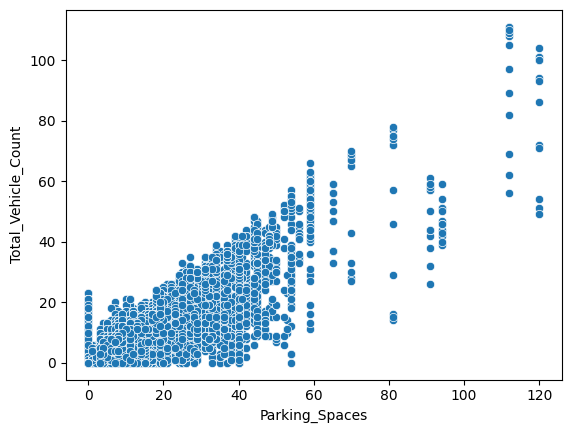

In [69]:
# Correlation between Parking_Spaces and Total_Vehicle_Count
print(cleaned_csv_df.corr("Parking_Spaces", "Total_Vehicle_Count"))

# Scatterplot of Parking_Spaces vs Total_Vehicle_Count
sns.scatterplot(data=cleaned_csv_df.select("Parking_Spaces", "Total_Vehicle_Count").toPandas(), 
                x="Parking_Spaces",
                y="Total_Vehicle_Count")

There is a strong correlation between the number of parking spaces available and the number of parked vehicles, which is aligned with expectation. Logically, we will now proceed to understand the **occupancy rate, which reflects the utilisation**.

In [70]:
# Create new column and calculate the Occupancy Rate
cleaned_csv_df = cleaned_csv_df.withColumn("Occupancy_Rate",
                                           cleaned_csv_df["Total_Vehicle_Count"] / cleaned_csv_df["Parking_Spaces"])

0.18439411730860697


<Axes: xlabel='Parking_Spaces', ylabel='Occupancy_Rate'>

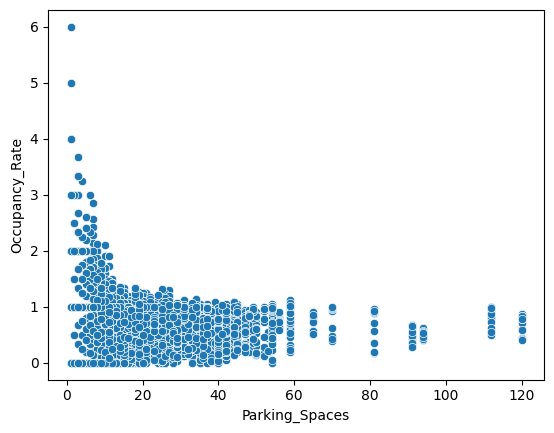

In [71]:
# Correlation between Parking_Spaces and Occupancy_Rate
print(cleaned_csv_df.corr("Parking_Spaces", "Occupancy_Rate"))

# Scatterplot of Parking_Spaces vs Occupancy_Rate
sns.scatterplot(data=cleaned_csv_df.select("Parking_Spaces", "Occupancy_Rate").toPandas(), 
                x="Parking_Spaces",
                y="Occupancy_Rate")

The weak correlation between parking spaces and occupancy rate confirms that occupancy is appropriately normalised and utilisation is not simply driven by size of parking spaces. This indicates that the different utilisation rates reflect the true variation in parking demand - we will therefore explore further how demand pressures varies across Seattle and identify possible strategies to optimise parking spaces in Seattle. 

In [72]:
# Summary Statistics for selected columns
cleaned_csv_df.select("Parking_Spaces", "Total_Vehicle_Count", "Occupancy_Rate").describe().toPandas()

,summary,Parking_Spaces,Total_Vehicle_Count,Occupancy_Rate
0,count,143861,143861,125678
1,mean,7.202362002210467,5.293234441579024,0.7527963667299918
2,stddev,6.477818743168298,5.227533077750868,0.3738006230177139
3,min,0,0,0.0
4,max,120,111,6.0


In [73]:
cleaned_csv_df.groupBy("Parking_Spaces") \
                .agg(F.avg("Total_Vehicle_Count").alias("avg_vehicle_count"),
                    F.avg("Occupancy_rate").alias("avg_occupancy_rate")) \
                .orderBy("Parking_Spaces") \
                .show(cleaned_csv_df.select("Parking_Spaces").distinct().count())

[Stage 461:============================>                            (1 + 1) / 2]

+--------------+------------------+------------------+
|Parking_Spaces| avg_vehicle_count|avg_occupancy_rate|
+--------------+------------------+------------------+
|             0|0.3430127041742287|              NULL|
|             1|0.8035143769968051|0.8035143769968051|
|             2|1.6206342834203131|0.8103171417101566|
|             3|2.3764266445320605|0.7921422148440199|
|             4|3.0132778755399134|0.7533194688849784|
|             5|3.9267449398544985|0.7853489879709022|
|             6|4.6105910097906095|0.7684318349651035|
|             7| 5.369954162353985|0.7671363089077083|
|             8| 6.114941657826943|0.7643677072283679|
|             9|6.7214258039519565|0.7468250893279943|
|            10| 7.307903152124258| 0.730790315212424|
|            11| 8.010421491431218|0.7282201355846584|
|            12| 8.447770502026817|0.7039808751689018|
|            13| 9.485812133072407| 0.729677856390185|
|            14| 9.802319961333978|0.7001657115238556|
|         

##### **3.1.2 json - Paid Parking Transaction Data**

In [74]:
# Summary Statistics for numerical columns
json_numeric_cols = []

for field in cleaned_json_df.schema.fields:
    if isinstance(field.dataType, NumericType):
        json_numeric_cols.append(field.name)

cleaned_json_df.select(json_numeric_cols).describe().toPandas()

,summary,amount_paid,durationinminutes,elementkey,latitude,longitude,meter_code,parkingspacenumber,transaction_id,Hour,Year
0,count,152739,152739,152739,152739,152739,152739,2627,152739,152739,152739
1,mean,3.927684743254899,85.71345235990808,44757.3856251514,47.62415569132159,-122.33749561078064,1.0674934213959761E7,297.99086410354016,1.5365807081078703E9,13.227466462396638,2025.0
2,stddev,3.716934800919739,88.06279578934303,28417.838853616962,0.023500394396898838,0.019325718845092724,5826353.369466665,227.9167932683912,603314.2374771262,3.334228121976851,0.0
3,min,-0.25,0,1001,47.55743593,-122.39716918,1001002,1,1535559424,3,2025
4,max,40.0,4320,136322,47.68090582,-122.28419469,23700030,797,1537595622,23,2025


In [75]:
# Correlation between amount_paid and durationinminutes
cleaned_json_df.corr("amount_paid", "durationinminutes")

0.36334921790625446

<Axes: xlabel='durationinminutes', ylabel='amount_paid'>

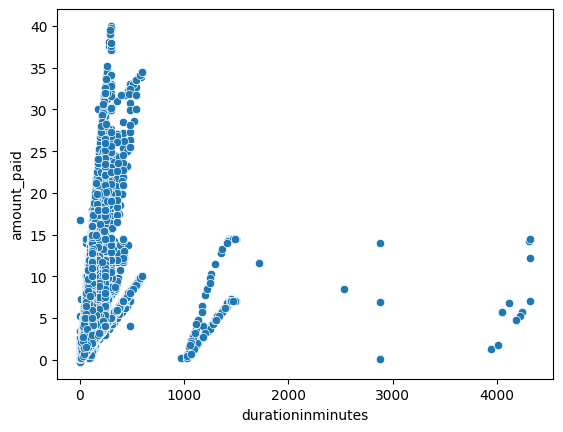

In [76]:
# Scatterplot of amount_paid vs durationinminutes
sns.scatterplot(data=cleaned_json_df.select("amount_paid", "durationinminutes").toPandas(), 
                x="durationinminutes",
                y="amount_paid")

The correlation between `amount_paid` and `durationinminutes` is moderately weak - While longer duration does correspond with slightly higher amounts paid, the relationship is noisy. This is likely because this dataset captures payment transactions, and hence the payment amount might not capture the full amount paid for the parking stay. For example, a single parking trip might involve multiple types of payments (e.g. via meter and then via phone).

Since the dataset does not include a unique identifier linking each transaction to a specific driver or parking session, the recorded amount paid does not necessarily represent the total amount paid for the associated stay. Additionally, pricing structures for parking spaces often adopt economies of scale in reality, which further weakens the linear relationship between duration and paymnet amount.

Given these limitations, we will not focus on the price vs duration as this could lead to misleading results. 

## *3.2 Categorical Variables*

##### ***3.2.1 csv - Annual Parking Study Data***

We will be analysing the following categorical variables:
- `Study_Area_cleaned_L2` and `Study_Area_cleaned_L1`
- `Side_cleaned`
- `Construction_cleaned`
- `EventClosure_cleaned`
- `PeakHour_cleaned`
- `Date`

In [77]:
# Count by Study_Area_cleaned_L2
cleaned_csv_df.groupBy("Study_Area_cleaned_L2").count().orderBy("count", ascending=False).toPandas()

,Study_Area_cleaned_L2,count
0,south lake union,16055
1,belltown,14773
2,first hill,12696
3,uptown,11191
4,pioneer square,10926
5,pike,10533
6,commercial core,10483
7,chinatown id,9736
8,ballard,7242
9,university district,6402


In [78]:
# Count by Study_Area_cleaned_L1
cleaned_csv_df.groupBy("Study_Area_cleaned_L1").count().orderBy("count", ascending=False).toPandas()

,Study_Area_cleaned_L1,count
0,south lake union,16055
1,belltown,14773
2,uptown,13564
3,commercial core,13378
4,first hill,12696
5,pioneer square,10926
6,pike,10533
7,chinatown id,9736
8,ballard,7716
9,denny triangle,6617


In [79]:
# Study Area by Mapping Levels
cleaned_csv_df.select("Study_Area_cleaned_L1","Study_Area_cleaned_L2").distinct().orderBy("Study_Area_cleaned_L1").toPandas()

,Study_Area_cleaned_L1,Study_Area_cleaned_L2
0,12th avenue,12th avenue
1,15th avenue,15th avenue
2,ballard,ballard locks
3,ballard,ballard
4,ballard,ballard locks spring
5,ballard,ballard locks summer
6,belltown,belltown
7,capitol hill,capitol hill
8,cherry hill,cherry hill
9,chinatown id,chinatown id


In [80]:
# Count by Side_cleaned
cleaned_csv_df.groupBy("Side_cleaned").count().orderBy("count", ascending=False).toPandas()

,Side_cleaned,count
0,W,23721
1,E,22190
2,S,20911
3,N,20784
4,NE,15600
5,SW,14598
6,SE,13902
7,NW,12155


In [81]:
# Count by Construction_cleaned
cleaned_csv_df.groupBy("Construction_cleaned").count().orderBy("count", ascending=False).toPandas()

,Construction_cleaned,count
0,False,131069
1,True,11848
2,None,944


In [82]:
# Count by EventClosure_cleaned
cleaned_csv_df.groupBy("EventClosure_cleaned").count().orderBy("count", ascending=False).toPandas()

,EventClosure_cleaned,count
0,False,131069
1,True,11848
2,None,944


In [83]:
# Count by PeakHour_cleaned
cleaned_csv_df.groupBy("PeakHour_cleaned").count().orderBy("count", ascending=False).toPandas()

,PeakHour_cleaned,count
0,False,139565
1,True,3257
2,None,1039


In [84]:
# Count by Hour
cleaned_csv_df.groupBy("Hour").count().orderBy("Hour").toPandas()

,Hour,count
0,0,433
1,1,95
2,2,95
3,7,35
4,8,10035
5,9,10037
6,10,10038
7,11,10035
8,12,10039
9,13,10039


From the 2 outputs above, we can conclude that the data in `PeakHour_cleaned` is not reliable for further analysis. Typically, a peak hour period falls between 07:00 - 09:00 / 17:00 - 19:00, however we are seeing a mismatch in results between the Count by PeakHour_cleaned and Count by Hour. This mismatch could be due to human error or wrong/ subjective understanding of peak hour by the data collectors. To answer the business questions below, we will therefore not analyse by the PeakHour_cleaned parameter. 

In [85]:
# Count by Date
cleaned_csv_df.groupBy("Date").count().orderBy("count", ascending=False).toPandas()

,Date,count
0,2015-04-14,2842
1,2016-06-02,2795
2,2014-04-26,2638
3,2017-05-09,2565
4,2014-04-17,2556
...,...,...
119,2017-07-11,39
120,2014-04-10,39
121,2015-07-16,39
122,2016-07-05,39


The analysis of the data above does not yield any immediate insights. We will create separate columns for month and day of the week to enable more meaningful analysis. 

In [86]:
# Create Month and Month_No columns
cleaned_csv_df = cleaned_csv_df.withColumn("Month", F.date_format("Date", "MMM"))
cleaned_csv_df = cleaned_csv_df.withColumn("Month_No", F.month("Date"))

cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Sub_Area,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Subarea Label,RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year,Occupancy_Rate,Month,Month_No
0,35889,North,VALLEY ST BETWEEN MINOR AVE N AND YALE AVE N,None,11,12,NaN,NaN,1.0,NaN,NaN,NaN,1x ill red curb,South Lake Union (North Subarea),0.0,Y,2017 Sep 27 10:22:00 AM,south lake union,south lake union,N,False,False,False,2017-09-27 10:00:00,2017-09-27,10:00,10,2017,1.090909,Sep,9
1,94732,PAID,NW 54TH SR ST BETWEEN 30TH WR AVE NW AND 32ND ...,None,40,0,NaN,NaN,NaN,NaN,NaN,NaN,None,Ballard Locks (PAID Subarea),NaN,None,2018 Jul 17 08:05:00 AM,ballard locks,ballard,S,False,False,False,2018-07-17 08:00:00,2018-07-17,08:00,8,2018,0.000000,Jul,7
2,65217,None,S HANFORD ST BETWEEN UTAH AVE S AND 1ST AVE S,None,7,2,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,0.0,N,2017 Jun 15 08:31:00 PM,sodo,sodo,N,False,False,False,2017-06-15 20:00:00,2017-06-15,20:00,20,2017,0.285714,Jun,6
3,12037,None,OCCIDENTAL AVE S BETWEEN S LANDER ST AND S FOR...,None,44,48,1.0,NaN,NaN,NaN,NaN,NaN,Double Parking,SODO,0.0,N,2017 Jun 15 11:30:00 AM,sodo,sodo,W,False,False,False,2017-06-15 11:00:00,2017-06-15,11:00,11,2017,1.090909,Jun,6
4,59062,Core,YESLER WAY BETWEEN OCCIDENTAL AVE S AND 2ND AVE,4-6PM,4,4,0.0,NaN,NaN,NaN,NaN,NaN,None,Pioneer Square (Core Subarea),0.0,Y,2016 Jun 15 08:05:00 PM,pioneer square,pioneer square,S,False,False,False,2016-06-15 20:00:00,2016-06-15,20:00,20,2016,1.000000,Jun,6


In [87]:
# Create DayOfWeek and DayOfWeek_No columns
cleaned_csv_df = cleaned_csv_df.withColumn("DayOfWeek", F.date_format("Date", "E"))
cleaned_csv_df = cleaned_csv_df.withColumn("DayofWeek_No", F.dayofweek("Date"))

cleaned_csv_df.limit(5).toPandas()

,Elmntkey,Sub_Area,Unitdesc,Peak Hour_SDOT,Parking_Spaces,Total_Vehicle_Count,Dp_Count,Rpz_Count,TG_Car2Go,BMW_DN,Lime,Idling,Field Notes,Subarea Label,RPZ Blocks,CSM,Time Stamp,Study_Area_cleaned_L2,Study_Area_cleaned_L1,Side_cleaned,Construction_cleaned,EventClosure_cleaned,PeakHour_cleaned,DateTime_cleaned,Date,Time,Hour,Year,Occupancy_Rate,Month,Month_No,DayOfWeek,DayofWeek_No
0,35889,North,VALLEY ST BETWEEN MINOR AVE N AND YALE AVE N,None,11,12,NaN,NaN,1.0,NaN,NaN,NaN,1x ill red curb,South Lake Union (North Subarea),0.0,Y,2017 Sep 27 10:22:00 AM,south lake union,south lake union,N,False,False,False,2017-09-27 10:00:00,2017-09-27,10:00,10,2017,1.090909,Sep,9,Wed,4
1,94732,PAID,NW 54TH SR ST BETWEEN 30TH WR AVE NW AND 32ND ...,None,40,0,NaN,NaN,NaN,NaN,NaN,NaN,None,Ballard Locks (PAID Subarea),NaN,None,2018 Jul 17 08:05:00 AM,ballard locks,ballard,S,False,False,False,2018-07-17 08:00:00,2018-07-17,08:00,8,2018,0.000000,Jul,7,Tue,3
2,65217,None,S HANFORD ST BETWEEN UTAH AVE S AND 1ST AVE S,None,7,2,NaN,NaN,NaN,NaN,NaN,NaN,None,SODO,0.0,N,2017 Jun 15 08:31:00 PM,sodo,sodo,N,False,False,False,2017-06-15 20:00:00,2017-06-15,20:00,20,2017,0.285714,Jun,6,Thu,5
3,12037,None,OCCIDENTAL AVE S BETWEEN S LANDER ST AND S FOR...,None,44,48,1.0,NaN,NaN,NaN,NaN,NaN,Double Parking,SODO,0.0,N,2017 Jun 15 11:30:00 AM,sodo,sodo,W,False,False,False,2017-06-15 11:00:00,2017-06-15,11:00,11,2017,1.090909,Jun,6,Thu,5
4,59062,Core,YESLER WAY BETWEEN OCCIDENTAL AVE S AND 2ND AVE,4-6PM,4,4,0.0,NaN,NaN,NaN,NaN,NaN,None,Pioneer Square (Core Subarea),0.0,Y,2016 Jun 15 08:05:00 PM,pioneer square,pioneer square,S,False,False,False,2016-06-15 20:00:00,2016-06-15,20:00,20,2016,1.000000,Jun,6,Wed,4


As shown in the above extract, the dayofweek() function follows the US convention, the day numbering begins on Sunday - Sunday = 1, Monday = 2 ... Saturday = 7. 

In [88]:
cleaned_csv_df.select("Month").distinct().show()

[Stage 636:>                                                        (0 + 2) / 2]

+-----+
|Month|
+-----+
|  Sep|
|  May|
|  Jun|
|  Mar|
|  Apr|
|  Jul|
+-----+



In [89]:
# Count by Month
cleaned_csv_df.groupBy("Month").count().orderBy("count", ascending=False).limit(12).toPandas()

,Month,count
0,Apr,67885
1,May,49891
2,Mar,11968
3,Jun,7986
4,Jul,3560
5,Sep,2571


The extract above shows that the data is skewed towards the months in Spring, consistent with the information on the website. Hence, we will not proceed with any analysis based on the month parameter, as the dataset contains inherent bias.

In [90]:
cleaned_csv_df.select("DayOfWeek").distinct().show()

[Stage 651:>                                                        (0 + 2) / 2]

+---------+
|DayOfWeek|
+---------+
|      Sun|
|      Thu|
|      Sat|
|      Wed|
|      Tue|
+---------+



In [91]:
# Count by DayOfWeek
cleaned_csv_df.groupBy("DayOfWeek").count().orderBy("count", ascending=False).toPandas()

,DayOfWeek,count
0,Tue,49432
1,Wed,44661
2,Thu,41211
3,Sat,4800
4,Sun,3757


Similar to the month-level analysis, we observe that the dataset heavily has data on mid-week (Tuesday to Thursday), with far fewer observations on weekends. Additionally, there are no observations for Mondays or Fridays. Given this inherent bias, we will not perform analyses based on days of the week or compare weekends with weekdays. 

##### ***3.2.2 json - Paid Parking Transaction Data***

In [92]:
# Count by sideofstreet
cleaned_json_df.groupBy("sideofstreet").count().orderBy("count",ascending=False).toPandas()

,sideofstreet,count
0,W,28946
1,E,26062
2,NE,20638
3,SW,19540
4,S,17111
5,N,16573
6,SE,12023
7,NW,11846


In [93]:
# Count by Date
cleaned_json_df.groupBy("Date").count().orderBy("count", ascending=False).toPandas()

,Date,count
0,2025-12-05,28011
1,2025-11-29,27253
2,2025-12-04,25602
3,2025-12-03,25461
4,2025-12-02,24156
5,2025-12-01,22256


The json dataset contains only the most recent week of data from the date of extraction, and does not contain any historical data with timeframe that coincides exactly with the csv dataset. As such, direct combining the 2 datasets is not possible. However, useful insights can still be derived by examining and cross-referencing fields that exist in both datasets, using targeted lookups and validation where appropriate. 

## **4. Answering The Main Business Question:** `How should we optimise parking spaces across Seattle?`

We will address the main business question using a sequential three-step approach, while also taking into considerations the characteristics and limitations of the datasets identified in Part 3.

### **4.1. How does utilisation vary across Seattle?**

To address this question, we will examine parking availability and demand across Seattle using several dimensions: by study area, by side of the street, and by considering the impacts of construction and event closures. 

#### *A. Occupancy by Side of Street*

In [94]:
cleaned_csv_df.groupBy("Side_cleaned") \
    .agg(F.sum("Parking_Spaces").alias("Total_Parking_Spaces"),
         F.avg("Total_Vehicle_Count").alias("Avg_Vehicle_Count"),
         F.avg("Occupancy_Rate").alias("Avg_Occupancy_Rate")) \
    .orderBy(F.col("Avg_Occupancy_Rate").desc()) \
    .toPandas()

,Side_cleaned,Total_Parking_Spaces,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,SE,83258,4.568767,0.770519
1,NW,69436,4.289840,0.766754
2,SW,101360,5.309563,0.766666
3,W,215346,6.785211,0.762195
4,NE,97207,4.722244,0.754502
5,N,133659,4.586172,0.749387
6,S,141184,4.733059,0.737640
7,E,194689,6.282650,0.732391


**Insights:** The occupancy rate across all sides of the street remains relatively similar - ranging from 0.73 to 0.77. We can conclude that the side of street does not influence demand.

#### *B. Impact of Construction*

In [95]:
cleaned_csv_df.groupBy("Construction_cleaned") \
                .agg(F.count("*").alias("Count"),
                     F.avg("Total_Vehicle_Count").alias("Avg_Vehicle_Count"),
                     F.avg("Occupancy_Rate").alias("Avg_Occupancy_Rate"))\
                .filter(F.col("Construction_cleaned").isNotNull())\
                .orderBy("Avg_Vehicle_Count", ascending=False).toPandas()

,Construction_cleaned,Count,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,False,131069,5.662117,0.765974
1,True,11848,1.116222,0.306603


**Insights:** Construction has a significant impact on utilisation, reducing it from 0.77 to 0.31.

#### *C. Impact of Event Closure*

In [96]:
cleaned_csv_df.groupBy("EventClosure_cleaned") \
                .agg(F.count("*").alias("Count"),
                     F.avg("Total_Vehicle_Count").alias("Avg_Vehicle_Count"),
                     F.avg("Occupancy_Rate").alias("Avg_Occupancy_Rate"))\
                .filter(F.col("EventClosure_cleaned").isNotNull())\
                .orderBy("Avg_Vehicle_Count", ascending=False).toPandas()

,EventClosure_cleaned,Count,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,False,131069,5.662117,0.765974
1,True,11848,1.116222,0.306603


**Insights:** Similar to construction, the occurrence of an event also reduces utilisation, lowering it from 0.77 to 0.31.

#### *D. Occupancy by Study Area*

In [97]:
Occ_StudyArea = cleaned_csv_df.groupBy("Study_Area_cleaned_L1") \
                        .agg(F.avg("Parking_Spaces").alias("Avg_Parking_Spaces"),
                             F.avg("Total_Vehicle_Count").alias("Avg_Vehicle_Count"),
                             F.avg("Occupancy_Rate").alias("Avg_Occupancy_Rate")) \
                        .orderBy(F.col("Avg_Occupancy_Rate").desc())
                        
Occ_StudyArea.toPandas()

,Study_Area_cleaned_L1,Avg_Parking_Spaces,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,15th avenue,5.333333,4.979487,1.042762
1,first hill,6.482042,5.788437,0.887615
2,dexter,5.066667,3.800000,0.831658
3,cherry hill,11.004983,8.823090,0.804267
4,green lake,5.648811,4.566086,0.804018
5,capitol hill,9.058380,7.204645,0.784773
6,pike,5.981677,4.703503,0.769301
7,chinatown id,5.053102,3.802588,0.766158
8,pioneer square,5.212521,3.975563,0.764275
9,denny triangle,4.744446,3.660722,0.757917


**Insights:** 15th Avenue is the only area with an occupancy rate > 1, indicating that more vehicles were parked than the number of available spaces - likely reflects illegal parking activity and suggests that 15th Avenue is oversubscribed.

Areas with high utilisation (occupancy rate > 0.8) include First Hill, Dexter, Cherry Hill and Green Lake. These results align with the characteristics of these neighbourhoods: First Hill and Cherry Hill are medical hubs, Dexter has dense residential and commercial development, and Green Lake is a popular recreational area.

In contrast, Roosevelt, Little Saigon and Lake City show low utilisation (occupancy rate < 0.7), with Little Saigon and Lake city operating at less 50% occupancy. Notably, Little Saigon also has one of the highest numbers of available parking spaces.

***While utilisation is clearly impacted by construction and events, the largest variation in occupancy rates is observed across study areas. Therefore we will focus on study area as the primary dimension to draw actionable insights for optimising parking spaces.***

In [98]:
# Capture the areas with high occupancy
HighOcc_StudyArea = Occ_StudyArea.filter(F.col("Avg_Occupancy_Rate") > 0.80)
HighOcc_StudyArea.toPandas()

,Study_Area_cleaned_L1,Avg_Parking_Spaces,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,15th avenue,5.333333,4.979487,1.042762
1,first hill,6.482042,5.788437,0.887615
2,dexter,5.066667,3.800000,0.831658
3,cherry hill,11.004983,8.823090,0.804267
4,green lake,5.648811,4.566086,0.804018


In [99]:
# Capture the areas with low occupancy
LowOcc_StudyArea = Occ_StudyArea.filter(F.col("Avg_Occupancy_Rate") < 0.70)
LowOcc_StudyArea.toPandas()

,Study_Area_cleaned_L1,Avg_Parking_Spaces,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,sodo,18.181929,12.382173,0.678959
1,west seattle,13.175617,8.953556,0.666289
2,roosevelt,6.730719,3.773420,0.591555
3,little saigon,18.009381,7.469043,0.430252
4,lake city,12.561538,5.836538,0.388920


In [100]:
HighOcc_StudyArea_List = []
for i in HighOcc_StudyArea.collect():
    HighOcc_StudyArea_List.append(i["Study_Area_cleaned_L1"])

LowOcc_StudyArea_List = []
for i in LowOcc_StudyArea.collect():
    LowOcc_StudyArea_List.append(i["Study_Area_cleaned_L1"])

#### *E. Occupancy by Study Area and Construction*

To deepen our analysis by study areas, we will examine the impact of construction on the above two groups. In general, construction works have a persistent and structural impact (often lasting months at least) and affect driving routes, parking availability and commuting behaviour. 

In [101]:
Occ_StudyArea_Construction = cleaned_csv_df.groupBy("Study_Area_cleaned_L1", "Construction_cleaned") \
                        .agg(F.avg("Parking_Spaces").alias("Avg_Parking_Spaces"),
                             F.avg("Total_Vehicle_Count").alias("Avg_Vehicle_Count"),
                             F.avg("Occupancy_Rate").alias("Avg_Occupancy_Rate")) \
                        .orderBy(F.col("Avg_Occupancy_Rate").desc())

In [102]:
HighOcc_StudyArea_Construction = Occ_StudyArea_Construction\
                                    .filter(F.col("Study_Area_cleaned_L1").isin(HighOcc_StudyArea_List))\
                                    .filter(F.col("Construction_cleaned").isNotNull())\
                                    .orderBy("Study_Area_cleaned_L1")

HighOcc_StudyArea_Construction.toPandas()

,Study_Area_cleaned_L1,Construction_cleaned,Avg_Parking_Spaces,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,15th avenue,False,5.333333,4.979487,1.042762
1,cherry hill,False,11.004983,8.823090,0.804267
2,dexter,True,0.000000,0.000000,NaN
3,dexter,False,6.333333,4.750000,0.831658
4,first hill,True,3.559471,1.508076,0.346226
5,first hill,False,6.650422,6.027501,0.902607
6,green lake,True,0.800000,0.504762,0.000000
7,green lake,False,5.811086,4.701541,0.807185


In [103]:
LowOcc_StudyArea_Construction = Occ_StudyArea_Construction\
                                    .filter(F.col("Study_Area_cleaned_L1").isin(LowOcc_StudyArea_List))\
                                    .filter(F.col("Construction_cleaned").isNotNull())\
                                    .orderBy("Study_Area_cleaned_L1")

LowOcc_StudyArea_Construction.toPandas()

,Study_Area_cleaned_L1,Construction_cleaned,Avg_Parking_Spaces,Avg_Vehicle_Count,Avg_Occupancy_Rate
0,lake city,False,12.561538,5.836538,0.388920
1,little saigon,False,18.459615,7.655769,0.430252
2,little saigon,True,0.000000,0.000000,NaN
3,roosevelt,False,6.927059,4.056471,0.612854
4,roosevelt,True,4.239521,0.053892,0.019231
5,sodo,True,0.000000,0.000000,NaN
6,sodo,False,18.475186,12.581886,0.678959
7,west seattle,True,0.000000,2.200000,NaN
8,west seattle,False,13.369661,9.053019,0.666289


**Insights:** The results are broadly consistent with earlier findings that construction suppresses utilisation. In high-utilisation areas such as First Hill, the occupancy rate reaches around 0.90 when construction is absent. This indicates possible operation saturation where targeted increases in supply may be necessary to better accommodate the underlying demand. 

In contrast, low-utilisation areas maintain low occupancy rates even without construction, which reinforces the conclusion that these areas may present opportunities to repurpose the space or consider price reductions.

### **4.2. How has utilisation varied across the years?**

Now that we have established the high-utilisation and low-utilisation study areas based on the 2014 - 2019 aggregated data, we will now examine the yearly utilisation rates.

In [104]:
Year_StudyArea = (cleaned_csv_df.groupBy("Study_Area_cleaned_L1", "Year")
                    .agg(F.avg("Occupancy_Rate").alias("Avg_Occupancy")))

Year_StudyArea = (Year_StudyArea.withColumn("UtilCategory",
                                            F.when(F.col("Avg_Occupancy") > 0.80, "High")
                                            .when(F.col("Avg_Occupancy") < 0.70, "Low")
                                            .otherwise("Mid")))

In [105]:
UtilCategory_Summary = Year_StudyArea.groupBy("Study_Area_cleaned_L1")\
                                        .pivot("UtilCategory", ["High", "Mid", "Low"]).count()\
                                        .orderBy("High", ascending=False)

UtilCategory_Summary.toPandas()

,Study_Area_cleaned_L1,High,Mid,Low
0,first hill,6.0,NaN,NaN
1,green lake,4.0,2.0,NaN
2,pioneer square,3.0,2.0,1.0
3,cherry hill,3.0,3.0,NaN
4,uptown,2.0,1.0,3.0
5,capitol hill,2.0,3.0,1.0
6,south lake union,2.0,3.0,1.0
7,pike,2.0,4.0,NaN
8,westlake,2.0,1.0,2.0
9,fremont,1.0,3.0,2.0


The above table shows the number of times each area has fallen in different utilisation category bucket. First Hill has consistently been a high-utilisation area for all 6 years (count = 6.0), with Green Lake following closely behind (count = 4.0). For our earlier determined low-utilisation areas, we can see that Lake City and Little Saigon actually only has data for 1 year.

In [106]:
UtilCategory_Year = (Year_StudyArea
                       .select("Study_Area_cleaned_L1", "Year", "UtilCategory")
                       .groupBy("Study_Area_cleaned_L1")
                       .pivot("Year")
                       .agg(F.first("UtilCategory"))
                       .orderBy("2019", ascending=False))

def color_demand(val):
    if val == "High":
        return "background-color: #b6f2b6"   
    elif val == "Mid":
        return "background-color: #fff799"   
    elif val == "Low":
        return "background-color: #ff9999"   
    else:
        return ""   

UtilCategory_Year_Style = UtilCategory_Year.toPandas()\
                            .style.applymap(color_demand,
                                            subset=[c for c in UtilCategory_Year.toPandas().columns if c != "Study_Area_cleaned_L1"])
UtilCategory_Year_Style

/tmp/ipykernel_3206/298748895.py:19: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(color_demand,


,Study_Area_cleaned_L1,2014,2015,2016,2017,2018,2019
0,12th avenue,Mid,Mid,Mid,Mid,Mid,Mid
1,ballard,Low,Mid,Mid,Low,Mid,Mid
2,capitol hill,Mid,High,High,Mid,Low,Mid
3,cherry hill,Mid,High,High,Mid,High,Mid
4,chinatown id,Mid,Mid,Mid,Mid,Mid,Mid
5,pike,High,High,Mid,Mid,Mid,Mid
6,pioneer square,Low,High,High,High,Mid,Mid
7,south lake union,Mid,High,High,Mid,Low,Mid
8,university district,Low,Low,Mid,Mid,Mid,Mid
9,columbia city,None,High,None,None,Low,Low


Based on the tables above, we conclude the following study areas as high-demand and low-demand:
- **High-demand**: First Hill, Green Lake, Cherry Hill, West Lake, Uptown, Fremont
  - First Hill: High utilisation for all 6 years
  - Green Lake: High utilisation for 4 out of 6 years
  - Green Lake and Cherry Hill: High utilisation for 3 out of 6 years + overall utilisation > 0.8
  - West Lake, Uptown and Fremont: Moved from Mid utilisation to High utilisation in later years
- **Low-demand**: Roosevelt, Columbia City, Commercial Core
  - Roosevelt: Low utilisation for 5 out of 6 years
  - Columbia City: Low utilisation for later 2 years; had High utilisation in 2015
  - Commercial Core: Moved from Mid utilisation to Low utilisation in the later 2 years

In [107]:
HighOcc_StudyArea_Final = ["first hill", "green lake", "cherry hill", "westlake", "uptown", "fremont"]
LowOcc_StudyArea_Final = ["roosevelt", "columbia city", "commercial core"]

In [108]:
HighOcc_StudyArea_Final_List = [area for area in HighOcc_StudyArea_Final]
LowOcc_StudyArea_Final_List = [area for area in LowOcc_StudyArea_Final]

### **4.3. Are prices aligned with these Demand Study Areas?**

Now that we have established the high-demand and low-demand Study Areas, we will proceed to understand the pricing at these areas based on the latest json dataset.

***Note: Since the datasets have no overlaps in time, we assume that there are no drastic changes in utilisation category for each Study Area from 2019 to 2025.***

In [109]:
# Create a lookup table from csv data first
csv_lookup = cleaned_csv_df.withColumnRenamed("ElmntKey", "elementkey")\
                            .select("elementkey", "Study_Area_cleaned_L1")\
                            .dropDuplicates(["elementkey"])

In [110]:
# Extract key columns from json data for price analysis
json_PriceAnalysis = cleaned_json_df.select("elementkey", "amount_paid", "durationinminutes", "payment_mean")

In [111]:
# Left join both tables - join csv_lookup to json_PriceAnalysis (left)
PriceAnalysis_df = json_PriceAnalysis.join(csv_lookup, on="elementkey", how="left")

PriceAnalysis_df.limit(5).toPandas()

,elementkey,amount_paid,durationinminutes,payment_mean,Study_Area_cleaned_L1
0,13577,14.25,414,CREDIT CARD,westlake
1,13577,13.75,402,CREDIT CARD,westlake
2,120180,1.75,78,PHONE,westlake
3,36157,4.00,240,CREDIT CARD,westlake
4,120198,2.00,48,CREDIT CARD,westlake


In [112]:
# Checked whether there are significant unmapped study areas
unmapped_count = PriceAnalysis_df.filter(F.col("Study_Area_cleaned_L1").isNull()).count()
unmapped_pct = unmapped_count/ PriceAnalysis_df.count()

print(unmapped_count)
print(unmapped_pct)

[Stage 920:>                                                        (0 + 1) / 1]

7091
0.04642560184366796


#### *A. Prices and Occupancy by Study Areas*

In [113]:
# Price by Study area for High-demand areas
Price_HighOcc_StudyArea = PriceAnalysis_df.groupBy("Study_Area_cleaned_L1")\
                            .agg(F.avg("amount_paid").alias("Avg_Price"))\
                            .filter(F.lower(F.col("Study_Area_cleaned_L1")).isin(HighOcc_StudyArea_Final_List))\
                            .orderBy("Avg_Price")

Price_HighOcc_StudyArea.toPandas()

,Study_Area_cleaned_L1,Avg_Price
0,cherry hill,1.801053
1,uptown,3.180372
2,westlake,3.377782
3,green lake,3.548560
4,fremont,5.631119
5,first hill,5.669151


In [114]:
# Price by Study area for Low-demand areas
Price_LowOcc_StudyArea = PriceAnalysis_df.groupBy("Study_Area_cleaned_L1")\
                            .agg(F.avg("amount_paid").alias("Avg_Price"))\
                            .filter(F.lower(F.col("Study_Area_cleaned_L1")).isin(LowOcc_StudyArea_Final_List))\
                            .orderBy("Avg_Price")

Price_LowOcc_StudyArea.toPandas()

,Study_Area_cleaned_L1,Avg_Price
0,roosevelt,1.237441
1,commercial core,4.546366
2,columbia city,5.254067


## **5. Conclusion:** Connecting All the Dots

To connect the various parts of our analysis together, we can summarise with the following tables:

In [115]:
Occ_Year = (Year_StudyArea.select("Study_Area_cleaned_L1", "Year", "Avg_Occupancy")
                            .groupBy("Study_Area_cleaned_L1")
                            .pivot("Year")
                            .agg(F.first("Avg_Occupancy"))
                            .orderBy("Study_Area_cleaned_L1"))

In [116]:
Final_HighOcc = Price_HighOcc_StudyArea\
        .join(Occ_Year, "Study_Area_cleaned_L1", "left")\
        .join(Occ_StudyArea.select("Study_Area_cleaned_L1",
                                   F.col("Avg_Occupancy_Rate").alias("Avg_Occ (2014 - 2019)")),
              "Study_Area_cleaned_L1",
              "left")\
        .orderBy("2019", ascending=False)

Final_HighOcc = (Final_HighOcc.withColumnRenamed("Study_Area_cleaned_L1", "High_Demand_Area")
                                 .withColumnRenamed("Avg_Price", "Avg_Price_2025")
                                 .withColumnRenamed("2014", "Occ_2014")
                                 .withColumnRenamed("2015", "Occ_2015")
                                 .withColumnRenamed("2016", "Occ_2016")
                                 .withColumnRenamed("2017", "Occ_2017")
                                 .withColumnRenamed("2018", "Occ_2018")
                                 .withColumnRenamed("2019", "Occ_2019"))

Final_HighOcc.toPandas()

,High_Demand_Area,Avg_Price_2025,Occ_2014,Occ_2015,Occ_2016,Occ_2017,Occ_2018,Occ_2019,Avg_Occ (2014 - 2019)
0,first hill,5.669151,0.877464,0.927509,0.901019,0.867260,0.869651,0.890933,0.887615
1,westlake,3.377782,0.694306,0.635257,NaN,0.727053,0.807247,0.835726,0.728686
2,fremont,5.631119,0.626751,0.717905,0.704714,0.640146,0.746916,0.823523,0.705541
3,uptown,3.180372,0.655062,0.635567,0.840111,0.765791,0.676100,0.809581,0.754750
4,green lake,3.548560,0.816677,0.775679,0.884810,0.809089,0.772913,0.801402,0.804018
5,cherry hill,1.801053,0.778595,0.824042,0.802778,0.782566,0.850812,0.781128,0.804267


<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='Year', ylabel='Avg_Occupancy'>

Text(0.5, 1.0, 'Occupancy for High-Demand Areas Each Year')

Text(0, 0.5, 'Average Occupancy Rate')

Text(0.5, 0, 'Year')

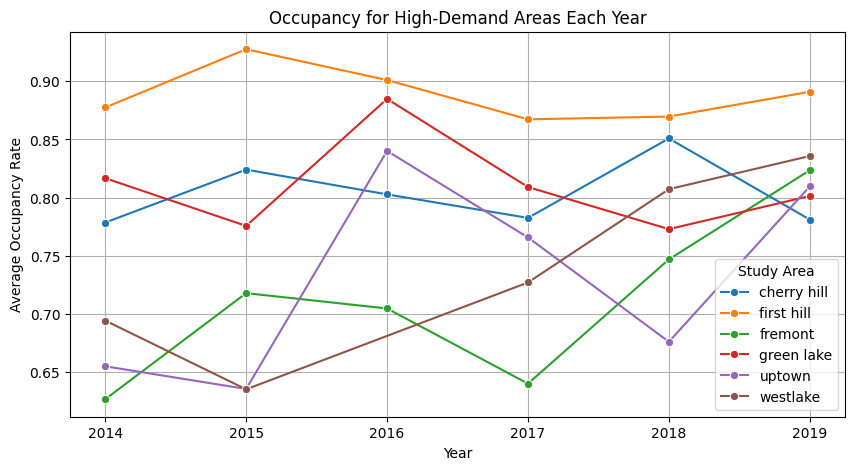

In [117]:
HighOcc_StudyArea_Trend = Year_StudyArea.filter(F.col("Study_Area_cleaned_L1")
                                                 .isin(HighOcc_StudyArea_Final))\
                           .orderBy("Study_Area_cleaned_L1", "Year")

plt.figure(figsize=(10,5))
sns.lineplot(
    data=HighOcc_StudyArea_Trend.toPandas(),
    x="Year",
    y="Avg_Occupancy",
    hue="Study_Area_cleaned_L1",
    marker="o")

plt.title("Occupancy for High-Demand Areas Each Year")
plt.ylabel("Average Occupancy Rate")
plt.xlabel("Year")
plt.legend(title="Study Area")
plt.grid(True)
plt.show()

In [118]:
Final_LowOcc = Price_LowOcc_StudyArea\
        .join(Occ_Year, "Study_Area_cleaned_L1", "left")\
        .join(Occ_StudyArea.select("Study_Area_cleaned_L1",
                                   F.col("Avg_Occupancy_Rate").alias("Avg_Occ (2014 - 2019)")),
              "Study_Area_cleaned_L1",
              "left")\
        .orderBy("2019", ascending=False)

Final_LowOcc = (Final_LowOcc.withColumnRenamed("Study_Area_cleaned_L1", "Low_Demand_Area")
                                 .withColumnRenamed("Avg_Price", "Avg_Price_2025")
                                 .withColumnRenamed("2014", "Occ_2014")
                                 .withColumnRenamed("2015", "Occ_2015")
                                 .withColumnRenamed("2016", "Occ_2016")
                                 .withColumnRenamed("2017", "Occ_2017")
                                 .withColumnRenamed("2018", "Occ_2018")
                                 .withColumnRenamed("2019", "Occ_2019"))

Final_LowOcc.toPandas()

,Low_Demand_Area,Avg_Price_2025,Occ_2014,Occ_2015,Occ_2016,Occ_2017,Occ_2018,Occ_2019,Avg_Occ (2014 - 2019)
0,columbia city,5.254067,NaN,0.968758,NaN,NaN,0.611949,0.698990,0.704198
1,commercial core,4.546366,0.721616,0.785468,0.745507,0.741276,0.642834,0.692226,0.716757
2,roosevelt,1.237441,0.474518,0.637161,0.607549,0.726630,0.570881,0.577892,0.591555


<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='Year', ylabel='Avg_Occupancy'>

Text(0.5, 1.0, 'Occupancy for Low-Demand Areas Each Year')

Text(0, 0.5, 'Average Occupancy Rate')

Text(0.5, 0, 'Year')

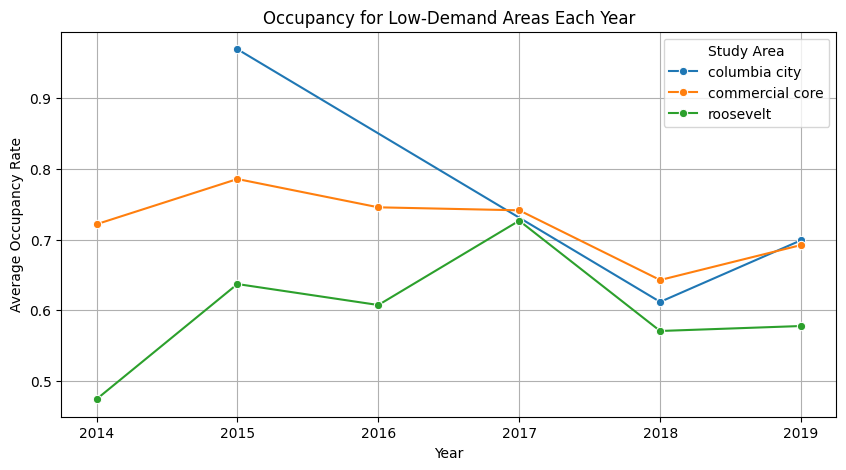

In [119]:
LowOcc_StudyArea_Trend = Year_StudyArea.filter(F.col("Study_Area_cleaned_L1")
                                                 .isin(LowOcc_StudyArea_Final))\
                           .orderBy("Study_Area_cleaned_L1", "Year")

plt.figure(figsize=(10,5))
sns.lineplot(
    data=LowOcc_StudyArea_Trend.toPandas(),
    x="Year",
    y="Avg_Occupancy",
    hue="Study_Area_cleaned_L1",
    marker="o")

plt.title("Occupancy for Low-Demand Areas Each Year")
plt.ylabel("Average Occupancy Rate")
plt.xlabel("Year")
plt.legend(title="Study Area")
plt.grid(True)
plt.show()

### **5.1. Recommendations**

Combining our analyses of historical data (2014 to 2019) and recent transaction data in 2025, we segment into 4 actionable categories:

**Category 1: Demand is High and Prices are High:**\
*First Hill, Fremont*\
Prices for these areas are consistent with the strong demand, signalling an appropriate pricing.

**Category 2: Demand is High and Prices are Lower:**\ *Cherry Hill, Green Lake, Uptown and Westlake*\
These high-demand areas have modest prices and lower prices than that of Category 1. This signals opportunities to revise prices upwards which could potentially improve parking turnover. Since utilisation remains high, a slight increase in prices here would likely increase overall revenue.

**Category 3: Demand is Low and Prices are High:**\
*Commercial Core, Columbia City*\
These areas do not show persistent demand and yet prices are high - It is likely that the higher prices have dampened an already lacklustre demand in these areas. This signals 2 opportunities:
   A. Revise prices downwards: To encourage organic demand and improve occupancy rates
   B. Reduce parking spaces and repurpose them for other public uses

**Category 4: Demand is Low and Prices are Low:**\
*Roosevelt*\
The lower prices match an already low demand in the area.

### **5.2. Limitations**

Both datasets present several limitations. Key issues include:
- **Different timeframes**: The csv dataset covers the period 2014 to 2019, while the json dataset only spans a week in 2025 (29 November 2025 to 5 December 2025).
- **Sampling bias**: The csv dataset is mostly from Tuesdays to Thursdays and in the Spring and Summer months only.
- **Data input quality**: Inconsistency in data inputs, likely due to manual data entry. 

### **5.3. Next Steps: Possible Further Analyses**

Once more comprehensive and complete datasets are made available, possible further analyses include:
- Expanding on time-dimension analysis, such as analysing how utilisation differ across months of the year, days of the week or over the past decade etc.
- Expanding on price-dimension analysis, such as analysing total parking fees per visit and deriving more insights on the price elasticity
- Expanding on other factors that could affect parking spaces such as the proximity to supermarkets, tourist attractions etc.

### **5.4. Overall Conclusion**

Overall, aligning parking rates with structural demand patterns provides a feasible path to help Seattle achieve more optimised parking spaces. High-demand areas could benefit from offering higher prices, while low-demand areas could either lower prices to encourage higher utilisation or repurpose these vacant places for other public uses.

We hope you have enjoyed our analysis and detailed walkthrough of our thought process and approach. :)